# What LiteLLM is

## Facade & Adapter

1. Present **Single & Simple Interface** (OpenAI format I/F).
2. **Coordinate Multiple Backend** LLMs.
3. Adapt to each Backend (convert OpenAI format to their formats).

```
                ┌───────────────────┐
App A, B, C ──► │                   │ ───► OpenAI
                │ LiteLLM SDK/Proxy │ ───► Anthropic
                │                   │ ───► Bedrock
                └───────────────────┘ ...
```
Why adapter?  
Adapter is **Conversion and Connect**. LiteLLM accept single I/F format (OpenAI) and convert to backend formats.

* [LiteLLM - Getting Started](https://docs.litellm.ai/docs/)
* [LiteLLM Cookbook](https://github.com/BerriAI/litellm/tree/main/cookbook)

# Setup

In [1]:
%%html
<style>
table {float:left}
</style>

In [2]:
import os
import sys
import json
import operator
from datetime import datetime, timedelta, timezone
from pathlib import Path
from typing import (
    List, Dict, Any, Literal, Optional, Callable, Annotated
)

import regex as re
from pydantic import BaseModel, Field
from tavily import TavilyClient
from langgraph.graph import StateGraph, START, END
import litellm
import mdformat
import trafilatura
from IPython.display import Markdown, display

for parent in [Path.cwd(), *Path.cwd().parents]:
    candidate = parent / "lib" / "code" / "python" / "lib" / "util_llm"
    if candidate.exists():
        sys.path.insert(0, str(candidate))
        break
else:
    raise FileNotFoundError("Could not locate lib/code/python/lib/util_llm")

from reranking import (
    RankingMetrics,
    RelevanceJudge,
    build_relevance_labels,
    build_result_document,
    evaluate_ranking_results,
    hit_rate_at_k,
    judge_result_with_llm,
    mean_reciprocal_rank,
    ndcg_at_k,
    precision_at_k,
    recall_at_k,
    rerank_results_cross_encoder,
    rerank_results_llm_judge,
    rerank_search_results,
    select_top_reranked_results,
)

## API Keys

In [3]:
path_to_openai_key:str = os.path.expanduser('~/.openai/api_key')
with open(path_to_openai_key, 'r', encoding='utf-8') as file:
    os.environ["OPENAI_API_KEY"] = file.read().strip()

path_to_tavily_key:str = os.path.expanduser('~/.tavily/api_key')
with open(path_to_tavily_key, 'r', encoding='utf-8') as file:
    os.environ["TAVILY_API_KEY"] = file.read().strip()

## Models

In [4]:
MODEL: str = "openai/gpt-4o"

---
# LiteLLM Facade - Chat/Completion

LiteLLM still uses Open AI deprecated Chat Completion API format.

* [LiteLLM API Reference - Chat Completions - POST
/chat/completions](https://developers.openai.com/api/reference/resources/chat/subresources/completions/methods/create)

> Creates a model response for the given chat conversation. Learn more in the text generation, vision, and audio guides. Returns a chat completion object, or a streamed sequence of chat completion chunk objects if the request is streamed.
> 
> **Returns:** <br>
> ```
> ChatCompletion = object { id, choices, created, 5 more }: Represents a chat completion response returned by model, based on the provided input.
> ```


In [5]:
def call_llm(
    messages: List[Dict[str, Any]],
    tools: Optional[List[Dict[str, Any]]] = None,
    stream: bool = False,
    model=MODEL,
):
    try:
        # responses is generator
        response = litellm.completion(
            model=model,
            messages=messages,
            tools=tools,
            stream=stream
        )
        return response
    except litellm.AuthenticationError as e:
        raise RuntimeError(f"Authentication failed: {e}") from e
    except litellm.RateLimitError as e:
        raise RuntimeError(f"Rate limited: {e}") from e
    except litellm.APIError as e:
        raise RuntimeError(f"API error: {e}") from e

## Batch

In constrat to **streaming**, send a one-off request to get one-off reply.

In [6]:
response: Dict[str, Any] = call_llm(messages=[{
    "role": "user",
    "content": "Hello, how are you?"
}])
print(json.dumps(response.model_dump(), indent=4, default=str))
del response

{
    "id": "chatcmpl-DMAYnzEcKuSVRHOLjUHnuwy46UiAn",
    "created": 1774176181,
    "model": "gpt-4o-2024-08-06",
    "object": "chat.completion",
    "system_fingerprint": "fp_e6c36a96dd",
    "choices": [
        {
            "finish_reason": "stop",
            "index": 0,
            "message": {
                "content": "Hello! I'm just a program, so I don't have feelings, but I'm here and ready to help you with your questions or tasks. How can I assist you today?",
                "role": "assistant",
                "tool_calls": null,
                "function_call": null,
                "provider_specific_fields": {
                    "refusal": null
                },
                "annotations": []
            },
            "provider_specific_fields": {}
        }
    ],
    "usage": {
        "completion_tokens": 34,
        "prompt_tokens": 13,
        "total_tokens": 47,
        "completion_tokens_details": {
            "accepted_prediction_tokens": 0,
         

## Streaming

In [7]:
response: Dict[str, Any] = call_llm(
    messages=[{
        "role": "user", "content": "Hello, how are you?"
    }],
    stream=True
)

# Iterate through the generator
for chunk in response:
    # Extract the content delta
    content = chunk.choices[0].delta.content
    
    if content:
        # print(..., end="", flush=True) creates the typewriter effect
        print(content, end="", flush=True)
        
print() # Print a newline when the stream finishes    
del response

Hello

!

 I'm

 just

 a

...

 I

 assist

 you

 today

?

---
# Tool Calling


#### Tool 

In [8]:
# Function for the Search Tool
search_tool: Callable = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])
if not hasattr(search_tool, "tool_name"):
    search_tool.name = "search_tool"

name_to_tool: Dict[str, Callable] = {
    # search_tool.name: search_tool.search
    search_tool.name: search_tool.search
}

#### Tool Parameters

Use Pydantic to generate the JSON Schema for the parameters.

In [9]:
# Parameters for the Search Tool
class SearchToolParameters(BaseModel):
    """
    Search the web for current events, news, or deep research.
    """
    query: str = Field(description="The search query to look up")
    
    topic: Literal["general", "news", "finance"] = Field(
        default="general",
        description="Category of search. Use 'news' for current events/politics, 'finance' for market data."
    )
    
    search_depth: Literal["basic", "advanced"] = Field(
        default="basic",
        description="Use 'basic' for quick facts. Use 'advanced' for complex queries needing more context."
    )
    
    time_range: Optional[Literal["day", "week", "month", "year"]] = Field(
        default=None,
        description="Filter results by publication date. Especially useful with topic='news'."
    )
    
    max_results: int = Field(
        default=5, ge=1, le=10,
        description="Number of search results to return."
    )

In [10]:
search_tool_parameters: Dict[str, Any] = SearchToolParameters.model_json_schema()
print(json.dumps(search_tool_parameters, indent=2, default=str))

{
  "description": "Search the web for current events, news, or deep research.",
  "properties": {
    "query": {
      "description": "The search query to look up",
      "title": "Query",
      "type": "string"
    },
    "topic": {
      "default": "general",
      "description": "Category of search. Use 'news' for current events/politics, 'finance' for market data.",
      "enum": [
        "general",
        "news",
        "finance"
      ],
      "title": "Topic",
      "type": "string"
    },
    "search_depth": {
      "default": "basic",
      "description": "Use 'basic' for quick facts. Use 'advanced' for complex queries needing more context.",
      "enum": [
        "basic",
        "advanced"
      ],
      "title": "Search Depth",
      "type": "string"
    },
    "time_range": {
      "anyOf": [
        {
          "enum": [
            "day",
            "week",
            "month",
            "year"
          ],
          "type": "string"
        },
        {
       

#### Tool Description

In [11]:
search_tool_description: str = SearchToolParameters.__doc__.strip()
print(search_tool_description)

Search the web for current events, news, or deep research.


### Tool Definition of the Tabiliy Web Search

In [12]:
search_tool_definition = {
    "type": "function",
    "function": {
        "name": search_tool.name,
        "description": search_tool_description,
        "parameters": search_tool_parameters
    }
}
print(json.dumps(search_tool_definition, indent=2, default=str))

{
  "type": "function",
  "function": {
    "name": "search_tool",
    "description": "Search the web for current events, news, or deep research.",
    "parameters": {
      "description": "Search the web for current events, news, or deep research.",
      "properties": {
        "query": {
          "description": "The search query to look up",
          "title": "Query",
          "type": "string"
        },
        "topic": {
          "default": "general",
          "description": "Category of search. Use 'news' for current events/politics, 'finance' for market data.",
          "enum": [
            "general",
            "news",
            "finance"
          ],
          "title": "Topic",
          "type": "string"
        },
        "search_depth": {
          "default": "basic",
          "description": "Use 'basic' for quick facts. Use 'advanced' for complex queries needing more context.",
          "enum": [
            "basic",
            "advanced"
          ],
         

### Tool Declartion for the Search

In [13]:
tool_declarations: List[Dict[str, Any]] = [
    search_tool_definition
]

### Messages to LLM

Build the the messages to LLM, which is prompt.

In [14]:
def in_time_window(result: Dict[str, Any], query: str, now: datetime) -> bool:
    """Return whether the result was published within the last month."""
    del query
    published_date = result.get("published_date")
    if not published_date:
        return False
    try:
        published_at = datetime.strptime(
            published_date, "%a, %d %b %Y %H:%M:%S %Z"
        ).replace(tzinfo=timezone.utc)
    except ValueError:
        return False
    return published_at >= (now - timedelta(days=30))

def is_bad_page_type(result: Dict[str, Any]) -> bool:
    """Return True for page types that are poor RAG evidence for this tutorial."""
    negative_markers = ('/event/', 'event', 'retreat', 'viewership', '/journalism/')
    title = str(result.get("title", "")).lower()
    url = str(result.get("url", "")).lower()
    return any(marker in title or marker in url for marker in negative_markers)

def keep_result(query: str, result: Dict[str, Any], now: datetime) -> bool:
    """Return True when a Tavily result is usable for the final answer."""
    if not in_time_window(result, query, now):
        return False
    if is_bad_page_type(result):
        return False
    if float(result.get("score", 0.0)) < 0.85:
        return False
    return True

def filter_search_results(results: List[Dict[str, Any]], query: str) -> List[Dict[str, Any]]:
    """Keep only search hits that are recent, relevant, and usable."""
    now = datetime.now(timezone.utc)
    return [result for result in results if keep_result(query, result, now)]

class SearchResultPipelineContext(BaseModel):
    """Pipeline state for search-result processing."""
    query: str
    results: List[Dict[str, Any]]

def apply_hard_filter(context: SearchResultPipelineContext) -> SearchResultPipelineContext:
    """Apply deterministic filtering before any reranking step."""
    return SearchResultPipelineContext(
        query=context.query,
        results=filter_search_results(results=context.results, query=context.query),
    )

def apply_llm_reranker(context: SearchResultPipelineContext) -> SearchResultPipelineContext:
    """Apply the shared LLM reranker to the current pipeline results."""
    if not context.results:
        return context
    reranked = rerank_search_results(
        query=context.query,
        results=context.results,
        strategy="llm_judge",
        min_score=0.7,
        limit=3,
    )
    return SearchResultPipelineContext(
        query=context.query,
        results=reranked or context.results[:3],
    )

SearchResultPipelineStep = Callable[[SearchResultPipelineContext], SearchResultPipelineContext]
SEARCH_RESULT_STEP_REGISTRY: Dict[str, SearchResultPipelineStep] = {
    "hard_filter": apply_hard_filter,
    "llm_reranker": apply_llm_reranker,
}
SEARCH_RESULT_PIPELINE_STEPS: List[str] = ["hard_filter", "llm_reranker"]

def build_search_result_pipeline(step_names: List[str]) -> SearchResultPipelineStep:
    """Build a search-result pipeline from registered step names."""
    steps = [SEARCH_RESULT_STEP_REGISTRY[name] for name in step_names]

    def pipeline(context: SearchResultPipelineContext) -> SearchResultPipelineContext:
        for step in steps:
            context = step(context)
        return context

    return pipeline

search_result_pipeline: SearchResultPipelineStep = build_search_result_pipeline(
    SEARCH_RESULT_PIPELINE_STEPS
)

def format_search_result(result: Dict[str, Any]) -> str:
    """Serialize one Tavily result as JSON for the tool response."""
    payload = {
        "title": result.get("title", ""),
        "url": result.get("url", ""),
        "content": result.get("content", ""),
        "published_date": result.get("published_date"),
    }
    return json.dumps(payload, ensure_ascii=False)

def execute_tool_calls(messages: List[Dict[str, str]]) -> List[Dict[str, str]]:
    """Execute tool calls requested by LLM.
    Args:
        messages: Messages for tool calls requests from LLM.
    Returns:
        messages_tool_outputs: 
            Tool output messages built from tool executions in the LiteLLM format.
            The messages are part of those to be sent back to LLM.
            The format for LiteLLM is [{
                "role": "tool",
                "tool_call_id": tool_call["id"],
                "name": func_name,
                "content": content
            }]
    """
    _messages_tool_outputs: List[Any] = []
    for _message in messages:
        for tool_call in _message.get('tool_calls', {}):
            if tool_call.get('type', '') != 'function':
                continue;

            func_name: str = tool_call['function']['name']
            func_args: Dict[str, str] = json.loads(tool_call['function']['arguments'])
            execution: Any = name_to_tool[func_name](**func_args)
            results = execution.get('results', [])
            if func_name == 'search_tool':
                results = search_result_pipeline(
                    SearchResultPipelineContext(
                        query=func_args.get('query', ''),
                        results=results,
                    )
                ).results
            if not results:
                content = json.dumps({
                    'query': func_args.get('query', ''),
                    'results': [],
                    'note': (
                        'No clearly relevant search results were found. '
                        'Ask for a narrower query or different source.'
                    )
                }, ensure_ascii=False)
            else:
                content = json.dumps({
                    'query': func_args.get('query', ''),
                    'results': [
                        json.loads(format_search_result(r)) for r in results
                    ]
                }, ensure_ascii=False)
            _messages_tool_outputs.append({
                "role": "tool",
                "tool_call_id": tool_call["id"],
                "name": func_name,
                "content": content
            })

    return _messages_tool_outputs

In [15]:
import markdown
from html.parser import HTMLParser

class _StripHTML(HTMLParser):
    """Extract plain text from HTML, used as fallback in render_content."""
    def __init__(self):
        super().__init__()
        self._parts = []
    def handle_data(self, data):
        self._parts.append(data)
    def get_text(self) -> str:
        return ''.join(self._parts)

def render_content(content: str, url: str) -> str:
    """Return clean plain text from url for display(Markdown(...)).
    Fetches original article text via trafilatura (preferred).
    Falls back to parsing the Tavily markdown snippet via the markdown
    package to strip heading/formatting artifacts.
    Args:
        content: Tavily markdown snippet (fallback source).
        url:     Original article URL (preferred source).
    """
    if url:
        downloaded = trafilatura.fetch_url(url)
        fetched = trafilatura.extract(downloaded) if downloaded else None
        if fetched:
            return fetched.replace('\xa0', ' ')
    # Fallback: markdown → HTML → strip tags → plain text
    html = markdown.markdown(content)
    extractor = _StripHTML()
    extractor.feed(html)
    return extractor.get_text().replace('\xa0', ' ')


In [16]:
def show_tool_executions(outputs: List[Dict[str, Any]]) -> None:
    """Display tool execution results.
    Parses JSON tool payloads and calls render_content(content, url)
    to fetch clean article text for display.
    """
    for msg in outputs:
        payload = json.loads(msg.get('content', '{}'))
        results = payload.get('results', [])
        if not results:
            note = payload.get('note', 'No tool results to display.')
            display(Markdown(note))
            continue
        for result in results:
            source = result.get('title', '')
            url = result.get('url', '')
            article_content = result.get('content', '')
            published_date = result.get('published_date')
            clean = render_content(content=article_content, url=url)
            header = f'**{source}**'
            if published_date:
                header += f'\n\nPublished: {published_date}'
            display(Markdown(f'{header}\n\n{clean}'))
            display(Markdown('---'))


---

## LangGraph Workflow

NOTE: **messages** in the LangGraph State corresponds with the entire message history with the Tool Call messages.

LangGraph accumuates the messages exchanged and genreated in the State.

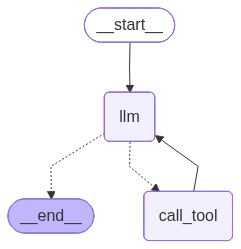

In [17]:
# LangGrph State Definition (Pydantic)
class AgentState(BaseModel):
    messages: Annotated[List[dict], operator.add] = Field(default_factory=list)

# Lang Graph Nodes
def call_model(state: AgentState):
    """Node to call the LLM
    """
    # Sends entire historical messages? Is it correct?
    response = call_llm(
        messages=state.messages, 
        tools=tool_declarations
    )
    return {"messages": [response.choices[0].message.model_dump()]}

def call_tool(state: AgentState):
    """Node to call a tool
    """
    last_msg = state.messages[-1]
    message_tool_outputs: List[Dict[str, Any]] = execute_tool_calls(messages=[last_msg])
    return {"messages": message_tool_outputs}
    
# 6. ROUTER & GRAPH
def router(state: AgentState) -> Literal["call_tool", "__end__"]:
    last_msg = state.messages[-1]
    return "call_tool" if last_msg.get("tool_calls") else "__end__"

builder = StateGraph(AgentState)
builder.add_node("llm", call_model)
builder.add_node("call_tool", call_tool)

builder.add_edge(START, "llm")
builder.add_conditional_edges("llm", router)
builder.add_edge("call_tool", "llm")
app = builder.compile()

app

In [18]:
# 7. EXECUTION
inputs = {
    'messages': [
        {
            'role': 'user',     # <--- Beware of the 'role' used
            'content': 'What are the top news headlines in AI from the last week?'
        }
    ]
}

for event in app.stream(inputs, stream_mode='values'):
    last_msg = event['messages'][-1]

    role = last_msg.get('role', 'assistant').upper() if isinstance(last_msg, dict) else last_msg.role.upper()
    tool_calls = last_msg.get('tool_calls') if isinstance(last_msg, dict) else getattr(last_msg, 'tool_calls', None)
    content = last_msg.get('content') if isinstance(last_msg, dict) else getattr(last_msg, 'content', '')

    if tool_calls:
        first_call = tool_calls[0]
        args_str = first_call['function']['arguments'] if isinstance(first_call, dict) else first_call.function.arguments
        params = json.loads(args_str)
        print(f'\n--- {role} (Calling Search with params: {params}) ---')

    elif role == 'TOOL' and content:
        print(f'\n--- {role} ---')
        show_tool_executions(outputs=[last_msg])

    else:
        print(f'\n--- {role} ---')
        if content:
            print(content)
            display(Markdown(content))
        else:
            print('Processing...')



--- USER ---
What are the top news headlines in AI from the last week?


What are the top news headlines in AI from the last week?


--- ASSISTANT (Calling Search with params: {'query': 'AI news', 'topic': 'news', 'search_depth': 'basic', 'time_range': 'week', 'max_results': 5}) ---



--- TOOL ---


No clearly relevant search results were found. Ask for a narrower query or different source.


--- ASSISTANT ---
It seems there were no specific search results for AI news in the past week. This might be due to a lack of prominent, specific events or updates in AI news during this period. If you have a more specific topic or another query, feel free to ask!


It seems there were no specific search results for AI news in the past week. This might be due to a lack of prominent, specific events or updates in AI news during this period. If you have a more specific topic or another query, feel free to ask!